# AIT Log Data Set V2.0 - fox

In [67]:
import pandas as pd
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Concatenate Sensor Files

In [51]:
dataset = "aitv2"
scenario = "santos"
data_dir = f"../data/interim/{dataset}/{scenario}/flows_labeled"
sensor_hosts = ["cloud_share", "inet_firewall", "internal_share", "intranet_server", "mail", "vpn", "webserver"]

In [294]:
# all_sensor_files = []
# for sensor_host in sensor_hosts:
#     df = pd.read_csv(
#         f"{data_dir}/{sensor_host}_labeled.csv"
#     )
#     df["sensor_host"] = sensor_host
#     all_sensor_files.append(df)

# df_all_sensors = pd.concat(all_sensor_files, ignore_index=True)
# df_all_sensors = df_all_sensors.sort_values("start_time").reset_index(drop=True)

# df_all_sensors.head()

In [52]:
df_all_sensors = pd.read_csv(f"{data_dir}/all_labeled.csv")

## Trim to Simulation Period

In [53]:
# Convert start_time and end_time from seconds to datetime
df_all_sensors["start_time_dt"] = pd.to_datetime(df_all_sensors["start_time"], unit="s")
df_all_sensors["end_time_dt"] = pd.to_datetime(df_all_sensors["end_time"], unit="s")

print(f"Full dataset time range: {df_all_sensors['start_time_dt'].min()} to {df_all_sensors['end_time_dt'].max()}")
print("Total flows in combined dataset:", len(df_all_sensors))

Full dataset time range: 2022-01-13 14:36:56.326056957 to 2022-01-18 05:41:41.618597031
Total flows in combined dataset: 438350


In [54]:
# Trim to simulation period
sim_start = pd.Timestamp("2022-01-14 00:00")
sim_end   = pd.Timestamp("2022-01-18 00:00")

df_sim = df_all_sensors[(df_all_sensors["start_time_dt"] >= sim_start) & (df_all_sensors["end_time_dt"] <= sim_end)]

print(f"Simulation period: {sim_start} to {sim_end}")
print(f"Total flows in simulation period: {len(df_sim)}")

Simulation period: 2022-01-14 00:00:00 to 2022-01-18 00:00:00
Total flows in simulation period: 407262


## Sanity Check Labeling

### Load Netflow Data

In [55]:
netflows_path = f"../data/interim/{dataset}/{scenario}/labels/all_netflows.csv"

df_netflows = pd.read_csv(netflows_path)
df_netflows_labels_counts = df_netflows["label"].value_counts()
netflows_labels = df_netflows["label"].unique()

print(netflows_labels)
print(df_netflows_labels_counts)
print()

['browsing/update' 'service_scan' 'online_cracking' 'benign_share' 'proxy'
 'host_discover_dmz' 'SSH' 'mail' 'DNS'
 'update/command on unassigned port' 'monitoring' 'HTTP' 'HTTP(S) intra'
 'HTTPS' 'host_discover_local' 'dirb_scan' 'wpscan' 'upload_rce_shell'
 'list_www' 'check_user_id' 'check_id' 'check_netstat_nat' 'check_whoami'
 'check_date' 'check_meminfo' 'check_netstat_l' 'check_who' 'check_pwd'
 'clear' 'check_network_config' 'list_l' 'check_uname_r' 'check_ps_a'
 'read_resolv' 'check_last' 'check_uptime' 'read_passwd' 'check_release'
 'check_netstat_t' 'check_df' 'list_web_dir' 'check_uname_a' 'list_home'
 'read_group' 'check_wp_config' 'dump_wp_users' 'dns_brute_force_start'
 'HTTP(S) DMZ' 'broken flow - benign' 'data exfiltration' 'NTP' 'mDNSv6'
 'mDNS' 'bootp' 'systemd-resolver (local)'
 'benign DNS - attacker requesting updates' 'benign DNS' 'QUIC' 'OpenVPN'
 'STUN VoIP' 'NetBIOS']
label
proxy              84132
benign DNS         70915
HTTP(S) DMZ        38200
browsing/upd

In [299]:
# netflows_dir = f"../data/raw/{dataset}/{scenario}/netflows"
# files = ["tcp_complete.csv", "tcp_nocomplete.csv", "udp_complete.csv"]

# for file in files:
#     netflows_path = f"{netflows_dir}/{file}"
#     df_netflows = pd.read_csv(netflows_path)
#     df_netflows_labels_counts = df_netflows["label"].value_counts()
#     netflows_labels = df_netflows["label"].unique()

#     print(f"Netflows file: {file}")
#     print(netflows_labels)
#     print(df_netflows_labels_counts)
#     print()

### Check Labeling

In [56]:
def get_observed_labels_and_counts(df):
    observed_labels = set()
    observed_labels_counts = {}
    for label in df["label"].unique():
        observed_labels.add(label)
        observed_labels_counts[label] = len(df[df["label"] == label])
    return observed_labels, observed_labels_counts

observed_labels, observed_labels_counts = get_observed_labels_and_counts(df_sim)

In [57]:
print("Unique labels observed across all sensors:")
print(list(observed_labels))

print("Labels in netflows but not observed:")
missing_labels = [label for label in netflows_labels if label not in observed_labels]
print(missing_labels)

Unique labels observed across all sensors:
['check_wp_config', 'browsing/update', 'check_last', 'check_user_id', 'dns_brute_force_start', 'check_whoami', 'host_discover_dmz', 'HTTP(S) DMZ', 'benign DNS', 'check_ps_a', 'check_uname_r', 'check_release', 'list_home', 'check_netstat_l', 'check_meminfo', 'check_network_config', 'monitoring', 'list_l', 'STUN VoIP', 'read_passwd', 'benign', 'HTTPS', 'list_www', 'update/command on unassigned port', 'upload_rce_shell', 'broken flow - benign', 'service_scan', 'read_resolv', 'check_netstat_nat', 'dump_wp_users', 'QUIC', 'bootp', 'wpscan', 'benign_share', 'check_id', 'proxy', 'check_df', 'check_who', 'host_discover_local', 'list_web_dir', 'read_group', 'online_cracking', 'SSH', 'check_date', 'clear', 'check_uptime', 'NTP', 'HTTP', 'check_uname_a', 'DNS', 'mail', 'OpenVPN', 'dirb_scan', 'check_pwd', 'HTTP(S) intra', 'check_netstat_t']
Labels in netflows but not observed:
['data exfiltration', 'mDNSv6', 'mDNS', 'systemd-resolver (local)', 'benign DN

In [58]:
indicators = []

missing_labels = ["data exfiltration"]
for missing_label in missing_labels:
    # print(f"Flows with label '{missing_label}' in netflows:")
    # print(df_netflows[df_netflows["label"] == missing_label])
    df_mis = df_netflows[df_netflows["label"] == missing_label]
    indicators.append(df_mis[["src_ip", "dst_ip", "sport", "dport"]].drop_duplicates())

# print("Indicators for missing labels:")
# for label, indicator in zip(missing_labels, indicators):
#     print(f"Label: {label}")
#     print(indicator)
#     print()

In [59]:
for label in observed_labels:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'check_wp_config': 4
Number of flows with label 'check_wp_config' in netflows: 2

Observed number of flows with label 'browsing/update': 26985
Number of flows with label 'browsing/update' in netflows: 29515

Observed number of flows with label 'check_last': 4
Number of flows with label 'check_last' in netflows: 2

Observed number of flows with label 'check_user_id': 4
Number of flows with label 'check_user_id' in netflows: 2

Observed number of flows with label 'dns_brute_force_start': 337
Number of flows with label 'dns_brute_force_start' in netflows: 325

Observed number of flows with label 'check_whoami': 4
Number of flows with label 'check_whoami' in netflows: 2

Observed number of flows with label 'host_discover_dmz': 225
Number of flows with label 'host_discover_dmz' in netflows: 115

Observed number of flows with label 'HTTP(S) DMZ': 38180
Number of flows with label 'HTTP(S) DMZ' in netflows: 38200

Observed number of flows with label 'benign 

### Remove Duplicates

In [60]:
def compute_hash(df: pd.DataFrame, columns: list) -> pd.Series:
    return (
        df[columns]
        .astype(str)
        .agg("|".join, axis=1)
        .apply(lambda x: hashlib.md5(x.encode()).hexdigest())
    )

In [61]:
df_sim["start_time_match"] = df_sim["start_time"].round(1)
df_sim["end_time_match"] = df_sim["end_time"].round(1)

match_columns = [col for col in df_sim.columns if col not in ["flow_id", "start_time", "end_time", "sensor_host"]]
match_columns.append("start_time_match")
match_columns.append("end_time_match")
print("Matching columns:", match_columns)

# Compute flow hash for all sensor flows
df_sim["flow_hash"] = compute_hash(df_sim, match_columns)

/tmp/ipykernel_56114/3310084976.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sim["start_time_match"] = df_sim["start_time"].round(1)
/tmp/ipykernel_56114/3310084976.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sim["end_time_match"] = df_sim["end_time"].round(1)


Matching columns: ['duration', 'src_ip', 'sport', 'dst_ip', 'dport', 'proto', 'service', 'orig_bytes', 'resp_bytes', 'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tunnel_parents', 'ip_proto', 'flow_hash', 'label', 'start_time_dt', 'end_time_dt', 'start_time_match', 'end_time_match', 'start_time_match', 'end_time_match']


/tmp/ipykernel_56114/3310084976.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sim["flow_hash"] = compute_hash(df_sim, match_columns)


In [62]:
# Remove duplicates by keeping only one entry per flow hash and sensor host
df_sim_no_duplicates = (
    df_sim
    .drop_duplicates(subset=["flow_hash", "sensor_host"])
    .drop(columns=["flow_hash", "start_time_match", "end_time_match"])
)

print("Original dataset shape:", df_sim.shape)
print("Final dataset shape:", df_sim_no_duplicates.shape)

Original dataset shape: (407262, 30)
Final dataset shape: (304090, 27)


In [63]:
observed_labels_no_duplicates, observed_labels_counts_no_duplicates = \
    get_observed_labels_and_counts(df_sim_no_duplicates)

for label in observed_labels_no_duplicates:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts_no_duplicates[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'check_wp_config': 2
Number of flows with label 'check_wp_config' in netflows: 2

Observed number of flows with label 'browsing/update': 26985
Number of flows with label 'browsing/update' in netflows: 29515

Observed number of flows with label 'check_last': 2
Number of flows with label 'check_last' in netflows: 2

Observed number of flows with label 'check_user_id': 2
Number of flows with label 'check_user_id' in netflows: 2

Observed number of flows with label 'dns_brute_force_start': 325
Number of flows with label 'dns_brute_force_start' in netflows: 325

Observed number of flows with label 'check_whoami': 2
Number of flows with label 'check_whoami' in netflows: 2

Observed number of flows with label 'host_discover_dmz': 115
Number of flows with label 'host_discover_dmz' in netflows: 115

Observed number of flows with label 'HTTP(S) DMZ': 38180
Number of flows with label 'HTTP(S) DMZ' in netflows: 38200

Observed number of flows with label 'benign 

### Save Final Dataset

In [64]:
df_sim_no_duplicates.to_csv(f"{data_dir}/all_labeled_sim.csv", index=False)
print("Combined dataset shape:", df_sim_no_duplicates.shape)
df_sim_no_duplicates.head()

Combined dataset shape: (304090, 27)


,flow_id,start_time,end_time,duration,src_ip,sport,dst_ip,dport,proto,service,...,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,sensor_host,start_time_dt,end_time_dt
27952,f1115,1.642118e+09,1.642118e+09,0.021806,172.21.128.54,55156,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-14 00:00:02.425734043,2022-01-14 00:00:02.447540045
27954,f3100,1.642118e+09,1.642118e+09,0.019958,172.21.128.54,55156,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-14 00:00:02.427603960,2022-01-14 00:00:02.447561979
27956,f1116,1.642118e+09,1.642118e+09,0.011838,172.21.128.54,55158,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-14 00:00:02.512283087,2022-01-14 00:00:02.524121046
27958,f3101,1.642118e+09,1.642118e+09,0.010949,172.21.128.54,55158,192.168.104.218,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-14 00:00:02.513200997,2022-01-14 00:00:02.524149895
27960,f3102,1.642118e+09,1.642118e+09,0.005656,192.168.104.218,35467,192.168.104.1,53,udp,dns,...,1,296,1,312,-,17,benign DNS,internal_share,2022-01-14 00:00:09.728241920,2022-01-14 00:00:09.733897924


## Plotting

In [65]:
df = df_sim_no_duplicates.copy()

### Plotting Functions

In [68]:
def plot_event_raster(df_attack, order, attack=False, invert_y=True):

    plt.figure(figsize=(14, 0.35 * len(order)))

    sample = df_attack.sample(
        min(len(df_attack), 5000),
        random_state=0
    ).sort_values("start_time_dt")

    label_to_idx = {lbl: i for i, lbl in enumerate(order)}

    ys = sample['label'].map(label_to_idx).astype(float)

    # jitter to reveal density
    ys += np.random.uniform(-0.15, 0.15, size=len(ys))

    # horizontal guides
    for y in label_to_idx.values():
        plt.axhline(y, color="lightgray", lw=0.5, zorder=0)

    plt.scatter(
        sample['start_time_dt'],  
        ys,
        s=2,
        alpha=0.5,
        rasterized=True
    )

    plt.yticks(list(label_to_idx.values()), list(label_to_idx.keys()))

    plt.grid(axis="x", linestyle=":", alpha=0.4)

    plt.xlabel("Time")
    plt.ylabel("Event Type")
    plt.title("Attack Event Timeline (Sampled Raster)", pad=12)

    ax = plt.gca()

    if attack:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.xticks(rotation=30)

    if invert_y:
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

### Analyze All Events

In [69]:
all_labels = list(netflows_labels)
all_labels.append("benign")
print("All labels (netflows + benign):", all_labels)

All labels (netflows + benign): ['browsing/update', 'service_scan', 'online_cracking', 'benign_share', 'proxy', 'host_discover_dmz', 'SSH', 'mail', 'DNS', 'update/command on unassigned port', 'monitoring', 'HTTP', 'HTTP(S) intra', 'HTTPS', 'host_discover_local', 'dirb_scan', 'wpscan', 'upload_rce_shell', 'list_www', 'check_user_id', 'check_id', 'check_netstat_nat', 'check_whoami', 'check_date', 'check_meminfo', 'check_netstat_l', 'check_who', 'check_pwd', 'clear', 'check_network_config', 'list_l', 'check_uname_r', 'check_ps_a', 'read_resolv', 'check_last', 'check_uptime', 'read_passwd', 'check_release', 'check_netstat_t', 'check_df', 'list_web_dir', 'check_uname_a', 'list_home', 'read_group', 'check_wp_config', 'dump_wp_users', 'dns_brute_force_start', 'HTTP(S) DMZ', 'broken flow - benign', 'data exfiltration', 'NTP', 'mDNSv6', 'mDNS', 'bootp', 'systemd-resolver (local)', 'benign DNS - attacker requesting updates', 'benign DNS', 'QUIC', 'OpenVPN', 'STUN VoIP', 'NetBIOS', 'benign']


In [70]:
phase_bounds_sim = (
    df[df['label'].isin(all_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_sim

,min,max
label,,
benign_share,2022-01-14 00:00:02.425734043,2022-01-17 23:45:02.306144953
benign DNS,2022-01-14 00:00:09.728241920,2022-01-17 23:58:37.136760950
benign,2022-01-14 00:00:23.517299890,2022-01-17 23:59:07.776370049
browsing/update,2022-01-14 00:00:23.922441006,2022-01-17 23:44:37.067908049
NTP,2022-01-14 00:04:11.079418898,2022-01-17 23:59:53.819441080
monitoring,2022-01-14 00:09:05.722054005,2022-01-17 23:39:05.678922892
HTTP(S) DMZ,2022-01-14 05:24:13.586384058,2022-01-17 22:21:53.315769911
proxy,2022-01-14 05:24:13.622169018,2022-01-17 22:21:53.331541061
mail,2022-01-14 05:39:41.157397032,2022-01-17 20:47:35.502568007


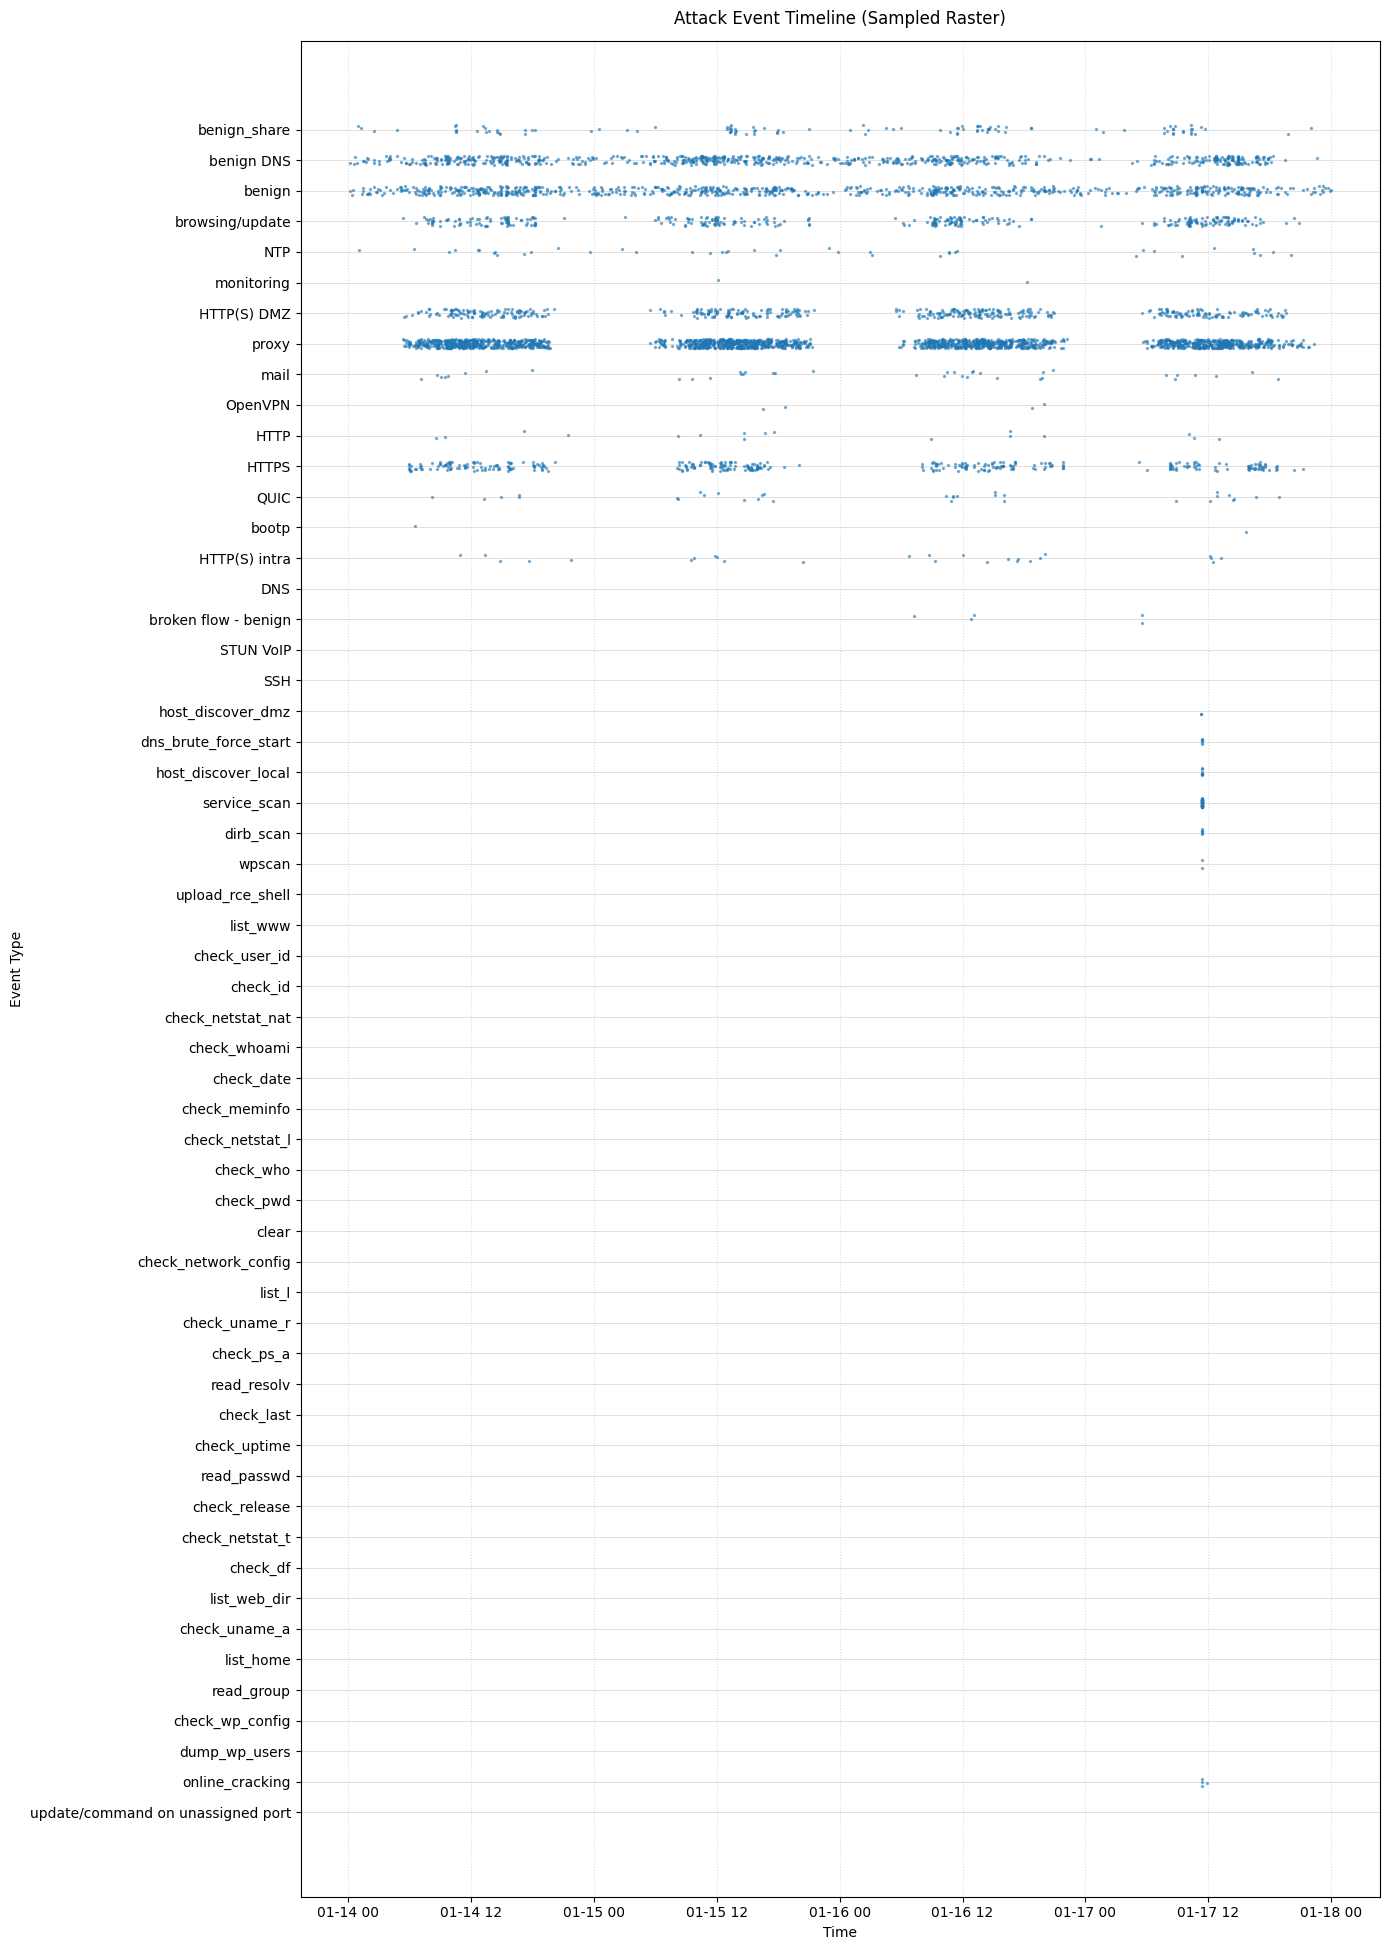

In [71]:
order_sim = phase_bounds_sim.index.tolist()
plot_event_raster(df_sim, order_sim)

### Only Attacks

In [72]:
benign_labels = ["DNS", "SSH", "HTTP(S) DMZ", "mail", "proxy", "HTTPS", "HTTP", "HTTP(S) intra", "browsing/update", "monitoring", "benign_share", "benign", "benign DNS", "NTP", "broken flow - benign", "bootp", "OpenVPN", "QUIC", "STUN VoIP"]
attack_labels = [lbl for lbl in all_labels if lbl not in benign_labels]
print("Benign labels:", benign_labels)
print("Attack labels:", attack_labels)

Benign labels: ['DNS', 'SSH', 'HTTP(S) DMZ', 'mail', 'proxy', 'HTTPS', 'HTTP', 'HTTP(S) intra', 'browsing/update', 'monitoring', 'benign_share', 'benign', 'benign DNS', 'NTP', 'broken flow - benign', 'bootp', 'OpenVPN', 'QUIC', 'STUN VoIP']
Attack labels: ['service_scan', 'online_cracking', 'host_discover_dmz', 'update/command on unassigned port', 'host_discover_local', 'dirb_scan', 'wpscan', 'upload_rce_shell', 'list_www', 'check_user_id', 'check_id', 'check_netstat_nat', 'check_whoami', 'check_date', 'check_meminfo', 'check_netstat_l', 'check_who', 'check_pwd', 'clear', 'check_network_config', 'list_l', 'check_uname_r', 'check_ps_a', 'read_resolv', 'check_last', 'check_uptime', 'read_passwd', 'check_release', 'check_netstat_t', 'check_df', 'list_web_dir', 'check_uname_a', 'list_home', 'read_group', 'check_wp_config', 'dump_wp_users', 'dns_brute_force_start', 'data exfiltration', 'mDNSv6', 'mDNS', 'systemd-resolver (local)', 'benign DNS - attacker requesting updates', 'NetBIOS']


In [73]:
attack_start_true = pd.Timestamp("2022-01-17 11:15")
attack_end_true   = pd.Timestamp("2022-01-17 11:59")

print(f"True attack period:")
print(f"{attack_start_true} to {attack_end_true}")
print()

df_attack = df[df["label"].isin(attack_labels)]
attack_start = df_attack["start_time_dt"].min()
attack_end = df_attack["end_time_dt"].max()

print(f"Attack period based on attack labels:")
print(f"{attack_start} to {attack_end}")
print()

print(f"Total attack flows in attack period: {len(df_attack)}")

True attack period:
2022-01-17 11:15:00 to 2022-01-17 11:59:00

Attack period based on attack labels:
2022-01-17 11:15:12.900707960 to 2022-01-17 11:58:57.603073120

Total attack flows in attack period: 5357


In [74]:
phase_bounds_attack = (
    df_attack[df_attack['label'].isin(attack_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_attack

,min,max
label,,
host_discover_dmz,2022-01-17 11:15:12.900707960,2022-01-17 11:20:35.309524059
dns_brute_force_start,2022-01-17 11:21:09.514715910,2022-01-17 11:21:10.257448911
host_discover_local,2022-01-17 11:21:21.226320028,2022-01-17 11:21:23.334497929
service_scan,2022-01-17 11:21:32.395858049,2022-01-17 11:21:46.958153009
dirb_scan,2022-01-17 11:22:02.550590038,2022-01-17 11:22:13.053563118
wpscan,2022-01-17 11:22:23.349515915,2022-01-17 11:22:44.917221069
upload_rce_shell,2022-01-17 11:22:57.162303925,2022-01-17 11:22:57.163022995
list_www,2022-01-17 11:23:00.339874029,2022-01-17 11:23:00.340250969
check_user_id,2022-01-17 11:23:03.510241984,2022-01-17 11:23:03.510807990


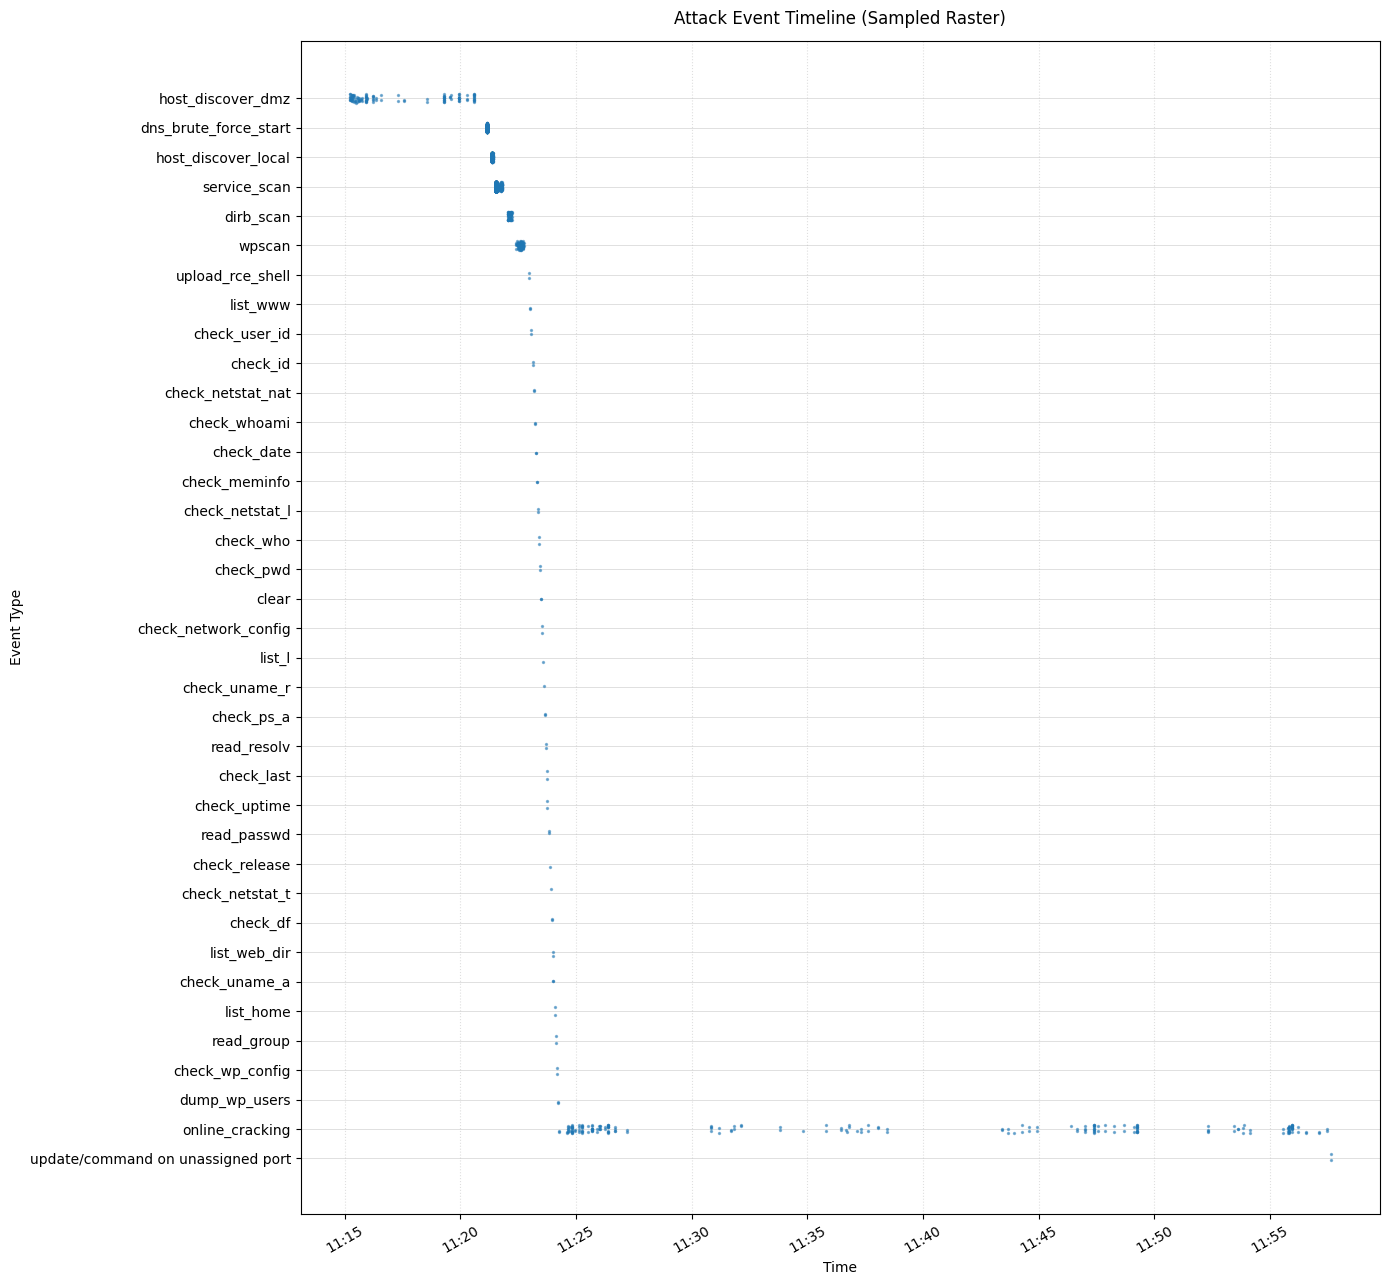

In [75]:
order_attack = phase_bounds_attack.index.tolist()
plot_event_raster(df_attack=df_attack, order=order_attack, attack=True)

## Dataset Statistics

In [85]:
def label_stats(df, sensor_host, plot_bar=True):
    label_counts = df["label"].value_counts()
    print("Label Distribution for {}:".format(sensor_host))
    print(label_counts)

    if plot_bar:
        bar = label_counts.plot(kind="bar")
        bar.set_title("Label Distribution - {}".format(sensor_host))
        bar.set_yscale("log")
    print()

In [77]:
def dataset_stats(df, print_details=True):
    total_flows = len(df)
    unique_src_ips = df["src_ip"].nunique()
    unique_dst_ips = df["dst_ip"].nunique()
    unique_src_ports = df["sport"].nunique()
    unique_dst_ports = df["dport"].nunique()

    if print_details:
        print(f"Total Flows: {total_flows}")
        print(f"Unique Source IPs: {unique_src_ips}")
        print(f"Unique Destination IPs: {unique_dst_ips}")
        print(f"Unique Source Ports: {unique_src_ports}")
        print(f"Unique Destination Ports: {unique_dst_ports}")

    return {
        "total_flows": total_flows,
        "unique_src_ips": unique_src_ips,
        "unique_dst_ips": unique_dst_ips,
        "unique_src_ports": unique_src_ports,
        "unique_dst_ports": unique_dst_ports,
    }

In [78]:
def dataset_stats_detailed(df, print_details=True):
    src_ips = df["src_ip"].value_counts()
    dst_ips = df["dst_ip"].value_counts()
    src_ports = df["sport"].value_counts()
    dst_ports = df["dport"].value_counts()

    if print_details:
        print("Total Flows:", len(df))

        print("\n --- IP distribution ---")
        print(f"\nSource IPs ({len(src_ips)}):")
        print(src_ips)
        print(f"\nDestination IPs ({len(dst_ips)}):")
        print(dst_ips)

        print("\n --- Port distribution ---")
        print(f"Source Ports ({len(src_ports)}):")
        print(src_ports)
        print(f"\nDestination Ports ({len(dst_ports)}):")
        print(dst_ports)

    return src_ips, dst_ips, src_ports, dst_ports

Label Distribution for All Sensors:
label
service_scan                         3461
host_discover_local                  1000
dns_brute_force_start                 325
online_cracking                       222
host_discover_dmz                     115
dirb_scan                              90
wpscan                                 84
list_www                                2
upload_rce_shell                        2
check_id                                2
check_netstat_nat                       2
check_whoami                            2
check_user_id                           2
check_meminfo                           2
check_netstat_l                         2
check_who                               2
check_pwd                               2
clear                                   2
check_network_config                    2
list_l                                  2
check_date                              2
check_uname_r                           2
check_ps_a                        

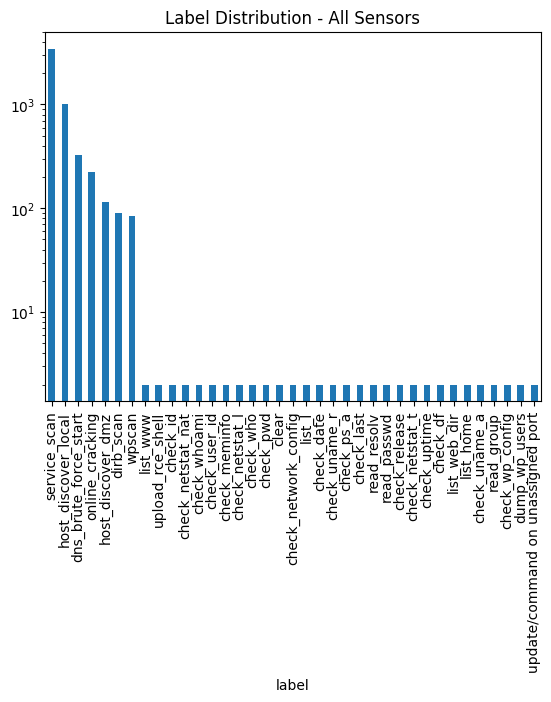

In [86]:
label_stats(df_attack, "All Sensors")

In [82]:
# Sim dataset stats
dataset_stats(df)

Total Flows: 304090
Unique Source IPs: 124
Unique Destination IPs: 3842
Unique Source Ports: 44171
Unique Destination Ports: 1065


{'total_flows': 304090,
 'unique_src_ips': 124,
 'unique_dst_ips': 3842,
 'unique_src_ports': 44171,
 'unique_dst_ports': 1065}

In [83]:
# Attack flows stats
dataset_stats(df_attack)

Total Flows: 5357
Unique Source IPs: 3
Unique Destination IPs: 263
Unique Source Ports: 3485
Unique Destination Ports: 593


{'total_flows': 5357,
 'unique_src_ips': 3,
 'unique_dst_ips': 263,
 'unique_src_ports': 3485,
 'unique_dst_ports': 593}

In [84]:
dataset_stats_detailed(df_attack)

Total Flows: 5357

 --- IP distribution ---

Source IPs (3):
src_ip
172.21.128.119     5353
192.168.104.155       2
10.229.0.4            2
Name: count, dtype: int64

Destination IPs (263):
dst_ip
192.168.104.155    1133
172.21.131.50       897
172.21.128.54       870
192.168.104.218     841
172.21.128.1        314
                   ... 
192.168.104.95        1
192.168.104.198       1
192.168.104.141       1
192.168.104.81        1
192.168.104.98        1
Name: count, Length: 263, dtype: int64

 --- Port distribution ---
Source Ports (3485):
sport
60056    6
35788    6
46186    6
35656    5
56148    5
        ..
44918    1
58342    1
48350    1
33222    1
41600    1
Name: count, Length: 3485, dtype: int64

Destination Ports (593):
dport
443      1094
80        605
587        25
139        13
993        13
         ... 
8873        4
5633        4
800         4
1088        4
16486       2
Name: count, Length: 593, dtype: int64


(src_ip
 172.21.128.119     5353
 192.168.104.155       2
 10.229.0.4            2
 Name: count, dtype: int64,
 dst_ip
 192.168.104.155    1133
 172.21.131.50       897
 172.21.128.54       870
 192.168.104.218     841
 172.21.128.1        314
                    ... 
 192.168.104.95        1
 192.168.104.198       1
 192.168.104.141       1
 192.168.104.81        1
 192.168.104.98        1
 Name: count, Length: 263, dtype: int64,
 sport
 60056    6
 35788    6
 46186    6
 35656    5
 56148    5
         ..
 44918    1
 58342    1
 48350    1
 33222    1
 41600    1
 Name: count, Length: 3485, dtype: int64,
 dport
 443      1094
 80        605
 587        25
 139        13
 993        13
          ... 
 8873        4
 5633        4
 800         4
 1088        4
 16486       2
 Name: count, Length: 593, dtype: int64)

## Multi-Step Attack Labels

In [326]:
recon = ['dns_brute_force_start', 'host_discover_local', 'host_discover_dmz', 'service_scan', 'wpscan', 'dirb_scan']
exploit = ['upload_rce_shell', 'check_user_id', 'check_netstat_t', 'read_resolv', 'check_network_config', 'check_ps_a', 'check_release', 'read_group', 'read_passwd', 'check_date', 'list_web_dir', 'check_wp_config', 'dump_wp_users', 'read_profile']
cracking = ['online_cracking']
escalation = ['update/command on unassigned port']

In [327]:
df_sim = pd.read_csv(f"{data_dir}/all_labeled_sim.csv")

In [328]:
def label_phase(label):
    if label in recon:
        return 1
    elif label in exploit:
        return 2
    elif label in cracking:
        return 3
    elif label in escalation:
        return 4
    else:
        return 0

df_sim["phase"] = df_sim["label"].apply(label_phase)
label_counts = df_sim["phase"].value_counts()
print("Phase distribution:")
print(label_counts)

Phase distribution:
phase
0    304843
1     53544
3        60
2        28
4         2
Name: count, dtype: int64


In [329]:
df_sim.to_csv(f"{data_dir}/all_flows_labeled.csv", index=False)